# QPSK Communication System Simulation

### Author: Manasvi Sharma  
**Domain:** Digital Communication Systems

This project implements a QPSK digital communication system over an AWGN channel and evaluates its performance using BER vs SNR analysis.

## 1. Introduction

Quadrature Phase Shift Keying (QPSK) is a digital modulation technique that transmits 2 bits per symbol by varying the phase of a carrier signal, improving bandwidth efficiency.

This project implements:
- QPSK modulation
- AWGN channel simulation
- Demodulation
- BER vs SNR analysis

## 2. Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt


## 3. Bit Generation

Random binary data is generated to simulate a digital source.

In [2]:
num_bit = 1000
bits = np.random.randint(0,2,num_bit)

## 4. QPSK Mapping

Each pair of bits is mapped to a complex symbol representing a point in the constellation.

In [3]:
symbols = bits.reshape(-1, 2)

mapping = {
    (0,0): 1+1j,
    (0,1): -1+1j,
    (1,1): -1-1j,   
    (1,0): 1-1j     
}
mapped_signal = np.array([mapping[tuple(b)] for b in symbols])

%matplotlib inline

## 5. Constellation Diagram

The QPSK constellation consists of four points representing 2-bit combinations.

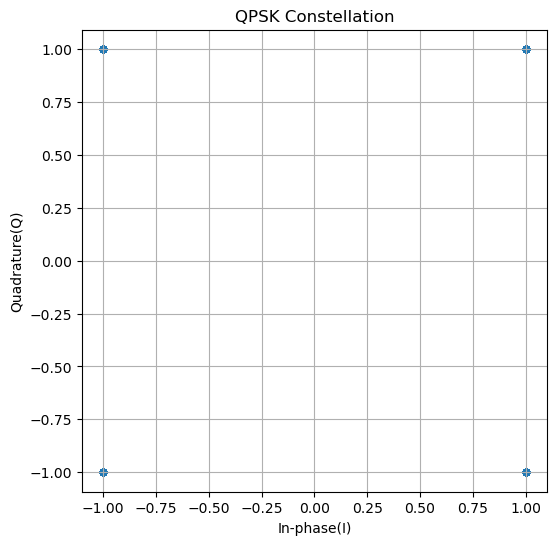

In [4]:
plt.figure(figsize=(6,6))
plt.scatter(mapped_signal.real, mapped_signal.imag, s=20)
plt.title("QPSK Constellation")
plt.xlabel("In-phase(I)")
plt.ylabel("Quadrature(Q)")

plt.axis('equal')
plt.grid()

plt.show()

## 6. AWGN Channel

Noise is added to simulate real-world transmission conditions.

In [5]:
noise = (np.random.randn(len(mapped_signal)) + 1j*np.random.randn(len(mapped_signal)))*0.1
received_signal = mapped_signal + noise

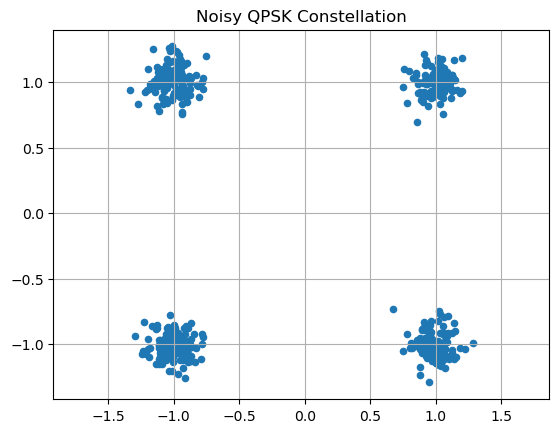

In [6]:
plt.figure()
plt.title("Noisy QPSK Constellation")
plt.grid()
plt.scatter(received_signal.real, received_signal.imag, s=20)
plt.axis('equal')

plt.show()

## 7. Demodulation

The receiver detects symbols based on their quadrant and recovers the original bits.

In [7]:
def demodulate(signal):
    detected_bits = []
    for s in signal:
        if s.real>0 and s.imag>0:
            detected_bits.extend([0,0])
        elif s.real<0 and s.imag>0:
            detected_bits.extend([0,1])
        elif s.real<0 and s.imag<0:
            detected_bits.extend([1,1])
        else:
            detected_bits.extend([1,0])

    return np.array(detected_bits)

received_bits = demodulate(received_signal)

## 8. Bit Error Rate (BER)

BER is calculated to evaluate system performance.

In [8]:
errors = np.sum(bits!= received_bits)
ber = errors/len(bits)

print("No. of errors:", errors)
print("BER:", ber)

No. of errors: 0
BER: 0.0


## 9. BER vs SNR Analysis

The BER is evaluated for different SNR values.

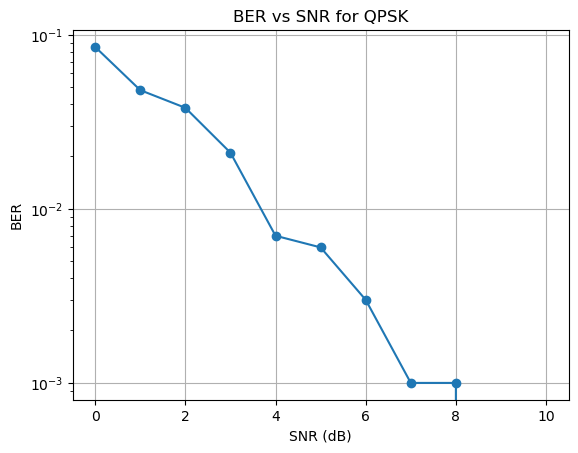

<Figure size 640x480 with 0 Axes>

In [9]:
snr_db = np.arange(0,11,1) #defining SNR range
ber_list = []

for snr in snr_db:
    snr = 10**(snr/10)
    noise_std = np.sqrt(1/(2*snr))
    noise = (np.random.randn(len(mapped_signal)) + 1j*np.random.randn(len(mapped_signal))) * noise_std
    
    received_signal = mapped_signal + noise
    
    received_bits = demodulate(received_signal)

    errors = np.sum(bits != received_bits)
    ber = errors/len(bits)

    ber_list.append(ber)

#Plot
plt.figure()
plt.semilogy(snr_db, ber_list, marker='o')
plt.title("BER vs SNR for QPSK")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.grid()

plt.show()

plt.savefig("ber_vs_snr.png")
    

## 10. Conclusion

The simulation shows that BER decreases with increasing SNR, validating theoretical expectations of QPSK systems.

This demonstrates the impact of noise on digital communication reliability.